Predicting Pulsar Stars 

For this project, I will be building a classification model that will predict whether a star is a pulsar star or 
not, based on radio emissions collected. A pulsar is a highly magnetic, rotating, neutron star, formed from 
the collapsed core of a star after it’s gone supernova. It emits beams of electromagnetic radiation that sweep 
across space, similar to a lighthouse beacon. 
The dataset that will be used is “Predicting Pulsar Star” from Dr Robert Lyon on Kaggle. 

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
df = pd.read_csv("Pulsar Data/pulsar_data_train.csv")
df.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
3,156.398438,48.865942,-0.215989,-0.171294,17.471572,NaN,2.958066,7.197842,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0


Data Wrangling

In [40]:
def wrangle(filepath):
    df = pd.read_csv(filepath)
    
# Clean column names
    df.columns = df.columns.str.strip()
    
# Drop dupes
    df = df.drop_duplicates()
    
# Drop missing values
    df = df.dropna()

# Remove outliers
    for col in df.columns:
        if col != 'target_class':   # don't remove based on target
            lower = df[col].quantile(0.01)
            upper = df[col].quantile(0.99)
            df = df[(df[col] >= lower) & (df[col] <= upper)]
    
    return df

In [41]:
df = wrangle("Pulsar Data/pulsar_data_train.csv")
df.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0
7,109.406250,55.912521,0.565106,0.056247,2.797659,19.496527,9.443282,97.374578,0.0


A wrangle function was used to import and clean the dataset. Column names were standardized by removing extra whitespace to ensure consistency. Duplicate rows were removed to maintain data integrity, and missing values were handled using row-wise deletion. No variables were identified with more than 50% missing values. Additionally, no high-cardinality, redundant, or leakage variables were present in the dataset. Outliers were removed using a quantile-based approach, where values outside the 1st and 99th percentiles were excluded for each feature.  

Exploratory Data Analysis

In [42]:
df['target_class'].value_counts()

target_class
0.0    7482
1.0     400
Name: count, dtype: int64

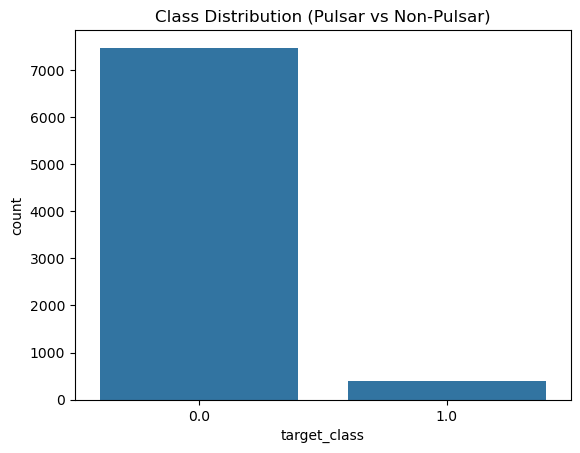

In [43]:
sns.countplot(x='target_class', data=df)
plt.title("Class Distribution (Pulsar vs Non-Pulsar)")
plt.show()

In [44]:
df.describe()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
count,7882.000000,7882.000000,7882.000000,7882.000000,7882.000000,7882.000000,7882.000000,7882.000000,7882.000000
mean,113.648274,46.594794,0.305976,0.671378,4.925811,22.063731,8.646399,100.716321,0.050749
std,18.683916,5.745239,0.485238,1.767830,7.930584,12.322996,3.226391,70.859663,0.219498
min,19.414062,30.674115,-0.367800,-0.721438,0.692308,10.215923,0.388678,-0.489357,0.000000
25%,102.599609,42.760957,0.032218,-0.183379,1.923286,14.428913,6.641856,47.943739,0.000000
50%,115.488281,46.916122,0.219857,0.185280,2.679766,17.833917,8.654763,88.341943,0.000000
75%,126.789062,50.810282,0.437652,0.802396,4.195234,24.650684,10.670006,138.416443,0.000000
max,155.460938,61.174327,3.904052,14.973286,109.214883,82.586470,17.760765,334.424262,1.000000


The dataset shows strong class imbalance, with approximately 5% of the samples belonging to the pulsar class. Several features exhibit high variance and significant skewness, particularly the DM-SNR-related variables, suggesting the presence of outliers and extreme values. Additionally, feature scales vary significantly, indicating that standardization will be required prior to modeling.

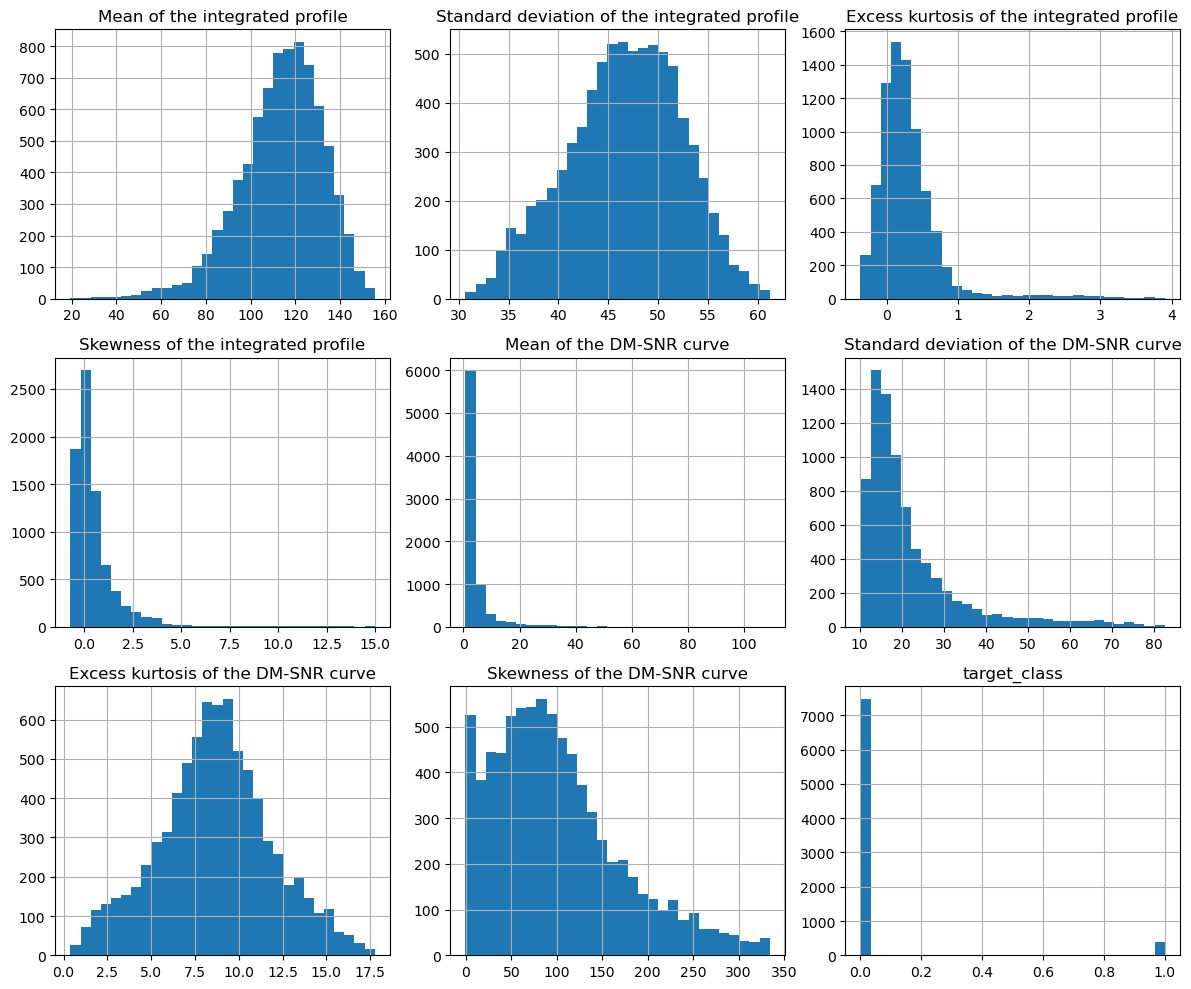

In [45]:
df.hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

The feature distributions are highly right-skewed, particularly the DM-SNR related variables. The dataset also shows a strong class imbalance, with non-pulsars dominating the target variable. Several features appear to contain discriminative structure but will likely require scaling and possibly transformation before modeling.

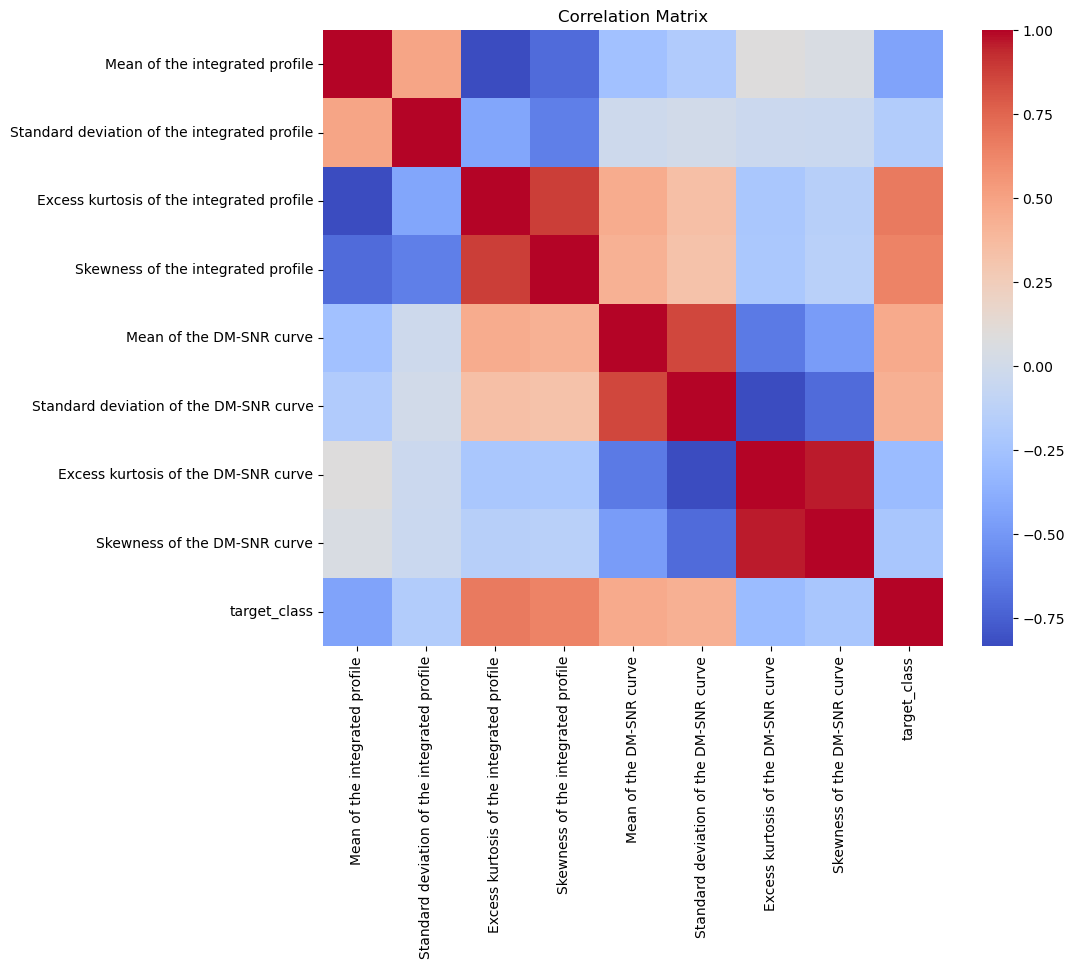

In [46]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows that several DM-SNR features and integrated profile statistics are strongly correlated with the target variable, indicating good predictive potential. However, there is also noticeable multicollinearity among features, particularly between skewness and kurtosis-based variables, suggesting redundancy in the dataset.

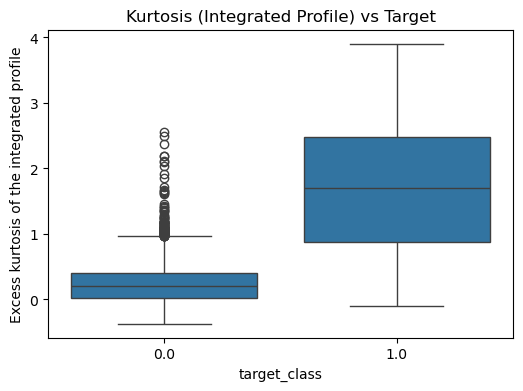

In [47]:
# Integrated Profile Kurtosis
plt.figure(figsize=(6,4))
sns.boxplot(x='target_class', y='Excess kurtosis of the integrated profile', data=df)
plt.title("Kurtosis (Integrated Profile) vs Target")
plt.show()

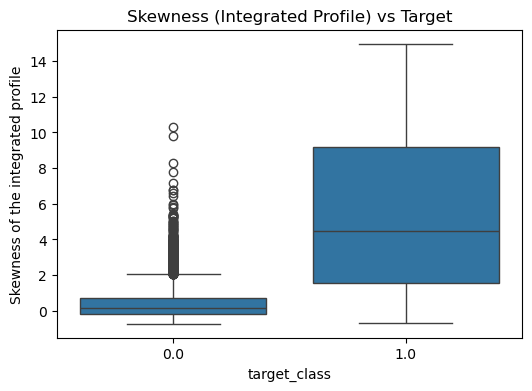

In [48]:
# Integrated Profile Skewness 
plt.figure(figsize=(6,4))
sns.boxplot(x='target_class', y='Skewness of the integrated profile', data=df)
plt.title("Skewness (Integrated Profile) vs Target")
plt.show()

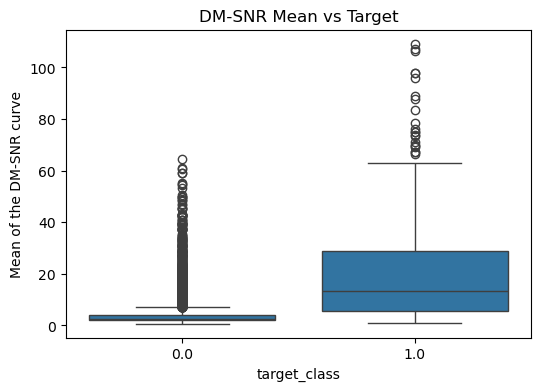

In [49]:
# DM-SNR Mean
plt.figure(figsize=(6,4))
sns.boxplot(x='target_class', y='Mean of the DM-SNR curve', data=df)
plt.title("DM-SNR Mean vs Target")
plt.show()

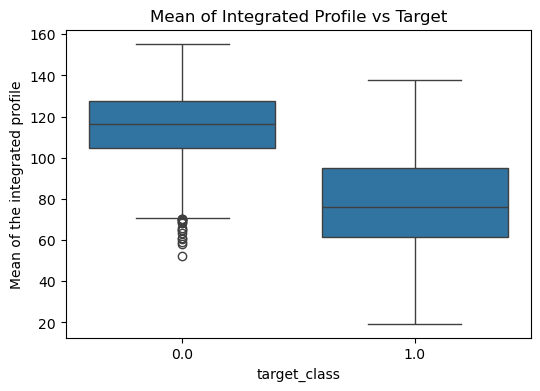

In [50]:
# Integrated Profile Mean
plt.figure(figsize=(6,4))
sns.boxplot(x='target_class', y='Mean of the integrated profile', data=df)
plt.title("Mean of Integrated Profile vs Target")
plt.show()

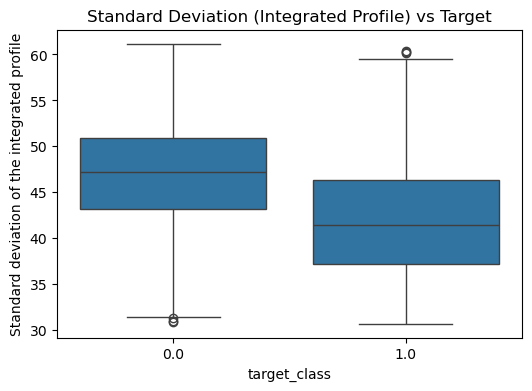

In [51]:
# Standard deviation of integrated profile
plt.figure(figsize=(6,4))
sns.boxplot(x='target_class', y='Standard deviation of the integrated profile', data=df)
plt.title("Standard Deviation (Integrated Profile) vs Target")
plt.show()

Boxplots show clear separation between pulsar and non-pulsar classes for kurtosis, skewness, and DM-SNR mean, suggesting strong predictive power.

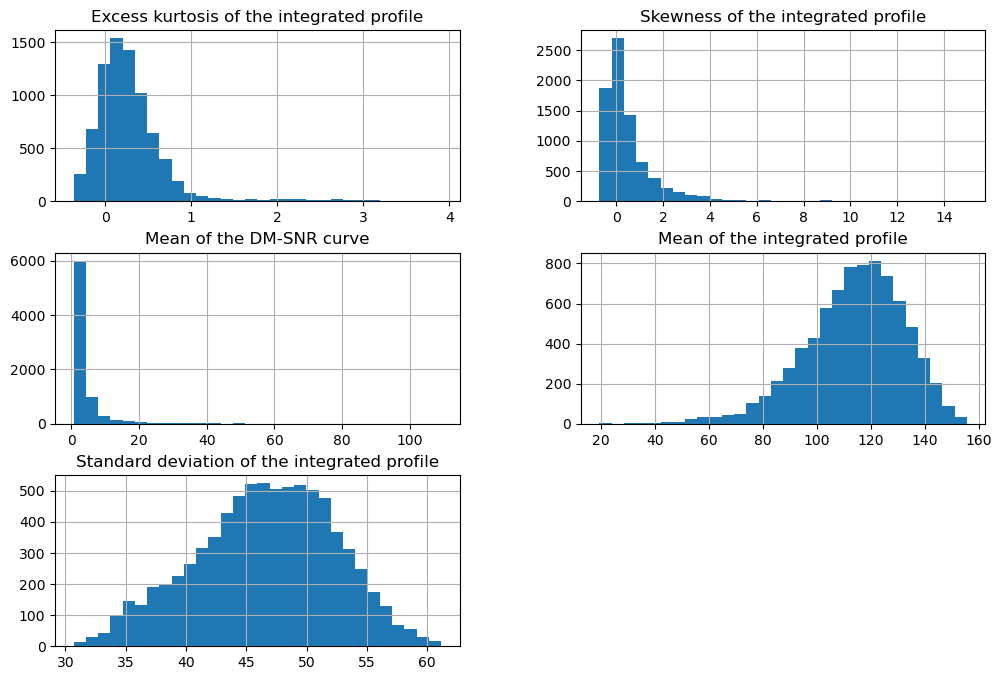

In [52]:
top_features = [
    'Excess kurtosis of the integrated profile',
    'Skewness of the integrated profile',
    'Mean of the DM-SNR curve',
    'Mean of the integrated profile',
    'Standard deviation of the integrated profile'
]
df[top_features].hist(bins=30, figsize=(12,8))
plt.show()

<Axes: xlabel='Mean of the integrated profile', ylabel='Standard deviation of the integrated profile'>

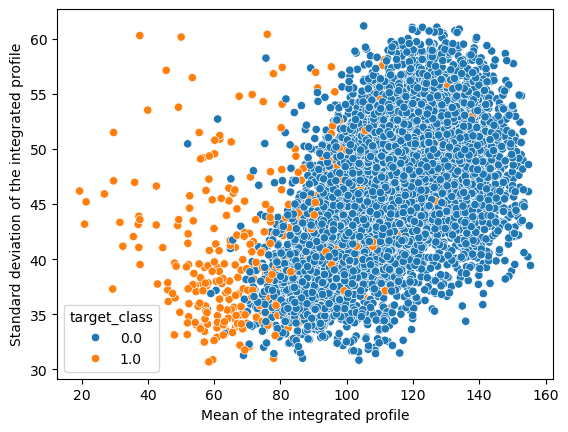

In [53]:
# Mean/ SD Integrated Profile
sns.scatterplot(
    x='Mean of the integrated profile',
    y='Standard deviation of the integrated profile',
    hue='target_class',
    data=df
)

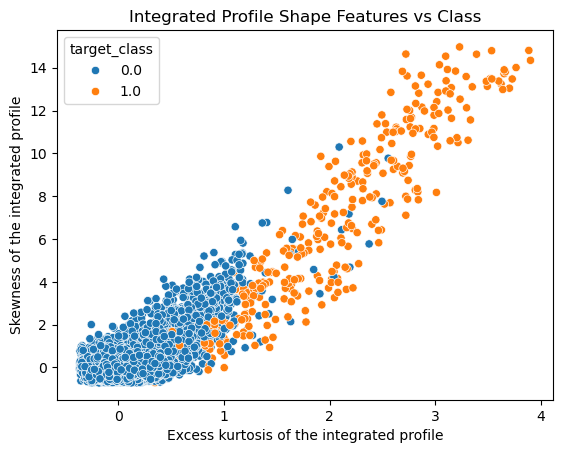

In [54]:
# Kurtosis/ Skewness
sns.scatterplot(
    x='Excess kurtosis of the integrated profile',
    y='Skewness of the integrated profile',
    hue='target_class',
    data=df
)
plt.title("Integrated Profile Shape Features vs Class")
plt.show()

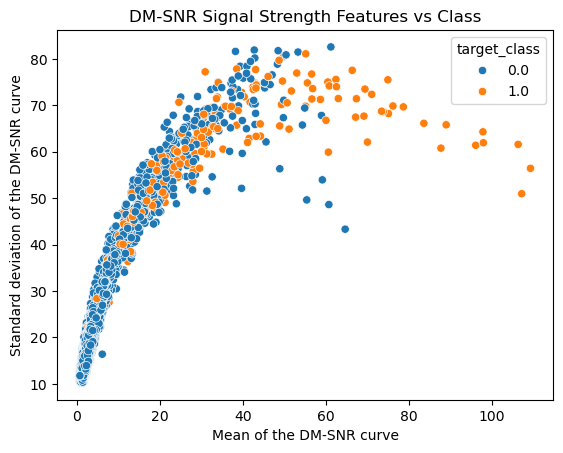

In [55]:
# DM-SNR Relationship 
sns.scatterplot(
    x='Mean of the DM-SNR curve',
    y='Standard deviation of the DM-SNR curve',
    hue='target_class',
    data=df
)
plt.title("DM-SNR Signal Strength Features vs Class")
plt.show()

Data Splitting

In [56]:
X = df.drop("target_class", axis=1)
y = df["target_class"]

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

The dataset was split into training and testing sets to evaluate the model performance. Stratified sampling was applied to preserve the original class distribution due to the imbalance.

Modeling (Random Forest)

In [59]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


A Random Forest classifier was selected due to its ability to capture non-linear relationships and handle complex feature interactions. Class weights were set to ‘balanced’ to address class imbalance.

Model Evaluation

In [60]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [61]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9809765377298668


In [62]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      1497
         1.0       0.95      0.66      0.78        80

    accuracy                           0.98      1577
   macro avg       0.96      0.83      0.88      1577
weighted avg       0.98      0.98      0.98      1577



In [63]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Confusion Matrix:
 [[1494    3]
 [  27   53]]


Conclusion

The model achieved high overall accuracy (98%), but due to class imbalance, performance on the pulsar class is better assessed using precision, recall, and F1-score. For the pulsar class, precision is high (0.95), indicating that positive predictions are generally reliable, while recall is lower (0.66), meaning that some actual pulsars are missed. The resulting F1-score of 0.78 reflects this trade-off, indicating moderate overall performance for the minority class.